In [ ]:
# for Numerical operations
import numpy as np

# fornData manipulation
import pandas as pd

# for Visualization
import matplotlib.pyplot as plt

# for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# for Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Optional: statistical analysis
import statsmodels.api as sm

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

In [ ]:
data = {
    "Hours_Studied": [
        1, 2, 2.5, 3, 3.5,
        4, 4.5, 5, 5.5, 6,
        6.5, 7, 7.5, 8, 8.5,
        9, 9.5, 10, 10.5, 11
    ],

    "Exam_Score": [
        42, 45, 47, 50, 52,
        55, 58, 60, 63, 66,
        68, 72, 74, 78, 80,
        83, 86, 89, 91, 94
    ]
}

df = pd.DataFrame(data)

df

,Hours_Studied,Exam_Score
0,1.0,42
1,2.0,45
2,2.5,47
3,3.0,50
4,3.5,52
5,4.0,55
6,4.5,58
7,5.0,60
8,5.5,63
9,6.0,66


In [ ]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (20, 2)


,Hours_Studied,Exam_Score
0,1.0,42
1,2.0,45
2,2.5,47
3,3.0,50
4,3.5,52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hours_Studied  20 non-null     float64
 1   Exam_Score     20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


In [ ]:
df.describe()

,Hours_Studied,Exam_Score
count,20.000,20.000
mean,6.225,67.650
std,3.002,16.346
min,1.000,42.000
25%,3.875,54.250
50%,6.250,67.000
75%,8.625,80.750
max,11.000,94.000


In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Exam_Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

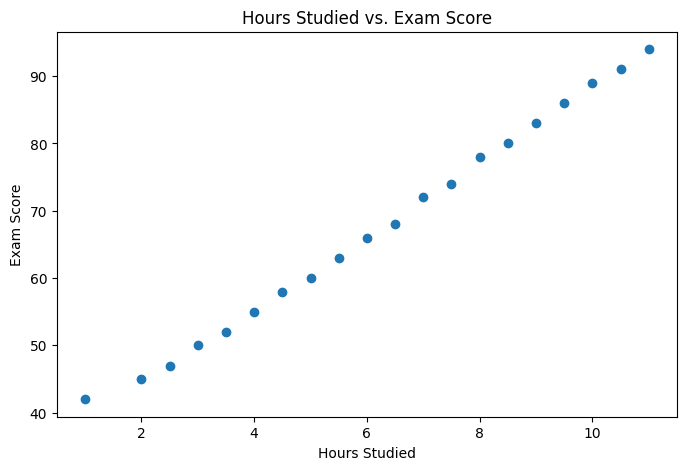

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Exam_Score"]
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs. Exam Score")

plt.show()

In [ ]:
correlation = df["Hours_Studied"].corr(df["Exam_Score"])

print("Correlation:", correlation)

Correlation: 0.9986214547513164


In [ ]:
X = df[["Hours_Studied"]]

y = df["Exam_Score"]

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,Hours_Studied
0,1.0
1,2.0
2,2.5
3,3.0
4,3.5



y:


,Exam_Score
0,42
1,45
2,47
3,50
4,52


In [ ]:
df["Hours_Studied"]

,Hours_Studied
0,1.0
1,2.0
2,2.5
3,3.0
4,3.5
5,4.0
6,4.5
7,5.0
8,5.5
9,6.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training features: (16, 1)
Testing features: (4, 1)
Training targets: (16,)
Testing targets: (4,)


In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 32.756597798220476
Coefficient: 5.5599457095460725


In [ ]:
y_pred = model.predict(X_test)

y_pred

array([38.31654351, 88.35605489, 82.79610918, 43.87648922])

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,42,38.317
1,89,88.356
2,83,82.796
3,45,43.876


In [ ]:
results["Residual"] = results["Actual"] - results["Predicted"]

results

,Actual,Predicted,Residual
0,42,38.317,3.683
1,89,88.356,0.644
2,83,82.796,0.204
3,45,43.876,1.124


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.413700799276123
MSE : 3.821591243434386
RMSE: 1.9548890616693282
R²  : 0.9916410854552358


In [ ]:
print("MAE:", mae)

MAE: 1.413700799276123


In [ ]:
print("MSE:", mse)

MSE: 3.821591243434386


In [ ]:
print("RMSE:", rmse)

RMSE: 1.9548890616693282


In [ ]:
print("R²:", r2)

R²: 0.9916410854552358


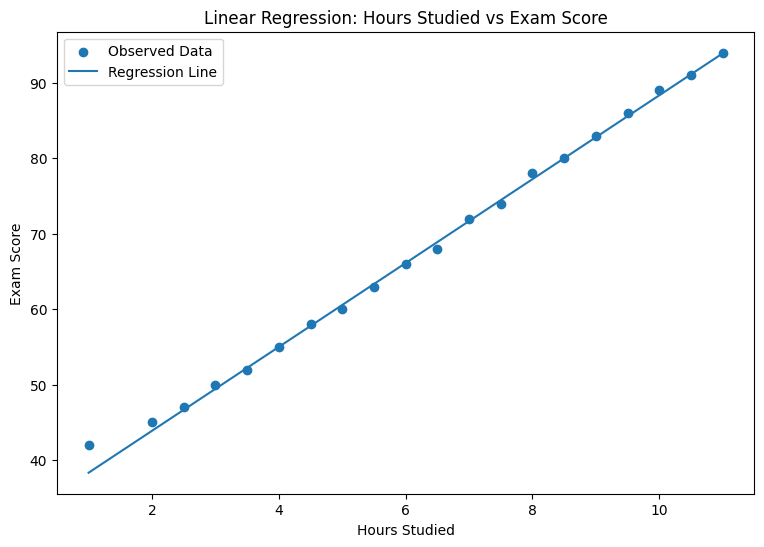

In [ ]:
X_sorted = X.sort_values("Hours_Studied")

y_line = model.predict(X_sorted)

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    label="Observed Data"
)

plt.plot(
    X_sorted,
    y_line,
    label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression: Hours Studied vs Exam Score")

plt.legend()

plt.show()

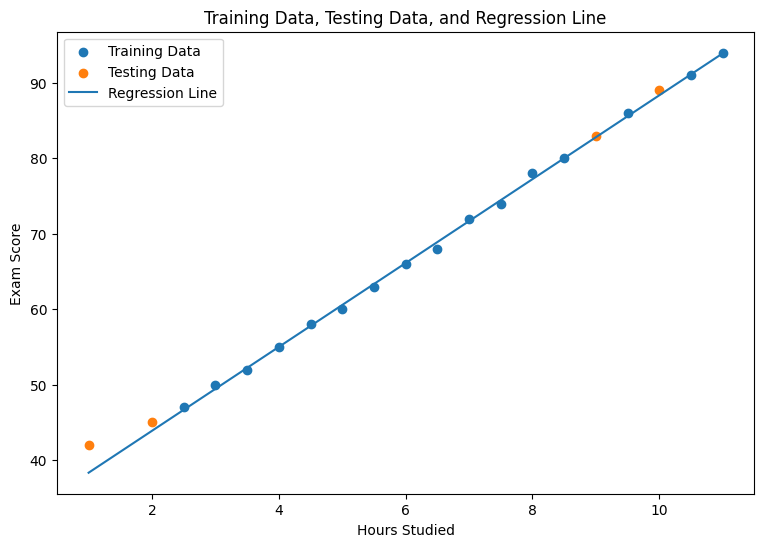

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    label="Testing Data"
)

plt.plot(
    X_sorted,
    y_line,
    label="Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Training Data, Testing Data, and Regression Line")

plt.legend()

plt.show()

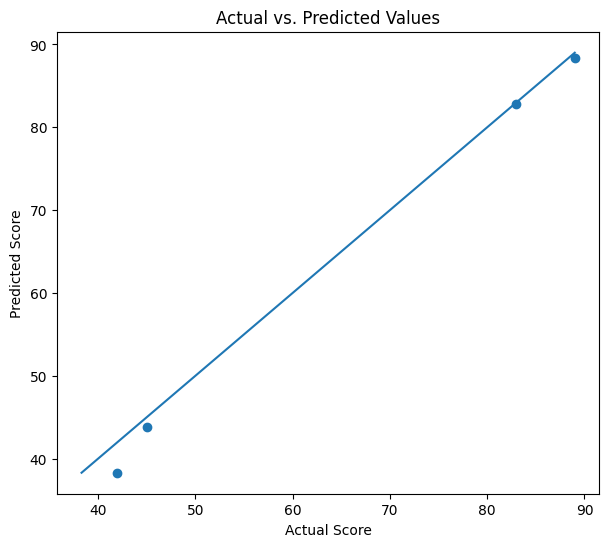

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs. Predicted Values")

plt.show()

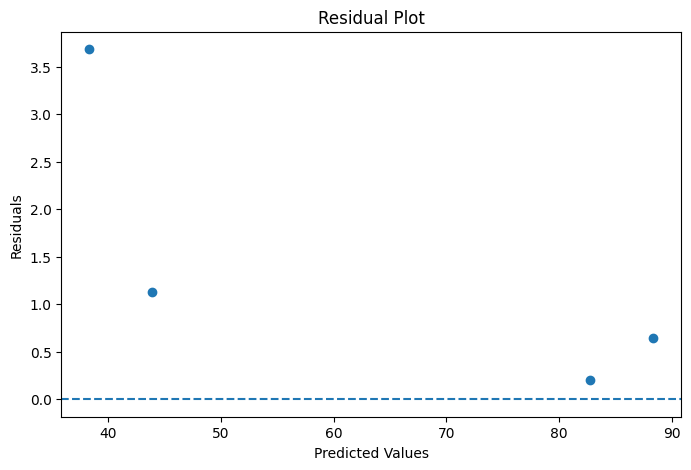

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

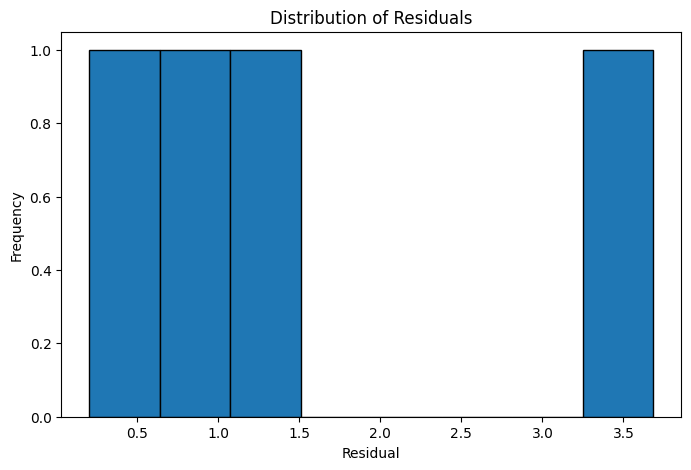

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=8,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [ ]:
new_student = pd.DataFrame({
    "Hours_Studied": [7.5]
})

predicted_score = model.predict(new_student)

print("Predicted Score:", predicted_score[0])

Predicted Score: 74.45619061981603


In [ ]:
hours = 7.5

new_student = pd.DataFrame({
    "Hours_Studied": [hours]
})

prediction = model.predict(new_student)[0]

print(f"Hours Studied: {hours}")
print(f"Predicted Exam Score: {prediction:.2f}")

Hours Studied: 7.5
Predicted Exam Score: 74.46


In [ ]:
def predict_exam_score(hours):
    new_data = pd.DataFrame({
        "Hours_Studied": [hours]
    })

    prediction = model.predict(new_data)[0]

    return prediction

In [ ]:
predict_exam_score(5)

np.float64(60.556326345950836)

In [ ]:
predict_exam_score(8)

np.float64(77.23616347458906)

In [ ]:
predict_exam_score(10)

np.float64(88.3560548936812)

In [ ]:
hours = pd.DataFrame({
    "Hours_Studied": [1, 3, 5, 7, 9, 11]
})

hours["Predicted_Score"] = model.predict(
    hours[["Hours_Studied"]]
)

hours

,Hours_Studied,Predicted_Score
0,1,38.317
1,3,49.436
2,5,60.556
3,7,71.676
4,9,82.796
5,11,93.916


In [ ]:
intercept = model.intercept_
slope = model.coef_[0]

print(
    f"Predicted Exam Score = "
    f"{intercept:.3f} + "
    f"{slope:.3f}(Hours Studied)"
)

Predicted Exam Score = 32.757 + 5.560(Hours Studied)


In [ ]:
X_stats = sm.add_constant(X)

stats_model = sm.OLS(y, X_stats).fit()

print(stats_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     6515.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.70e-24
Time:                        05:18:07   Log-Likelihood:                -24.803
No. Observations:                  20   AIC:                             53.61
Df Residuals:                      18   BIC:                             55.60
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            33.8026      0.463     72.952

In [ ]:
stats_model.conf_int()

,0,1
const,32.829,34.776
Hours_Studied,5.296,5.579


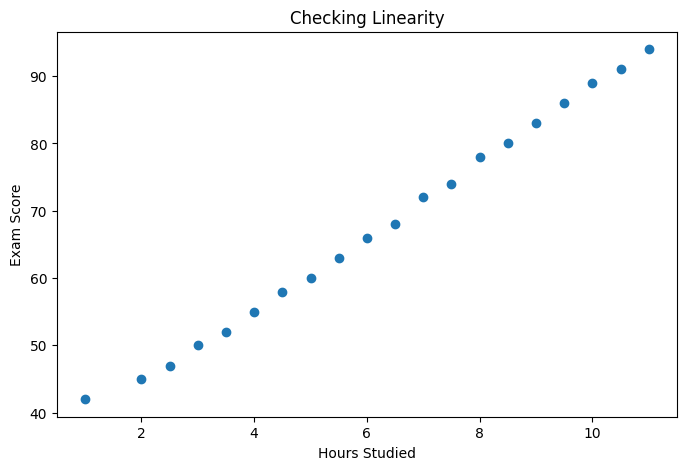

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours_Studied"],
    df["Exam_Score"]
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Checking Linearity")

plt.show()

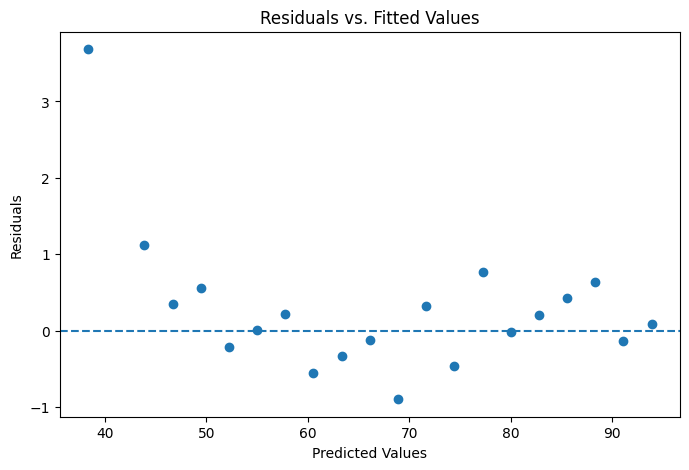

In [ ]:
all_predictions = model.predict(X)

all_residuals = y - all_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    all_predictions,
    all_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")

plt.show()

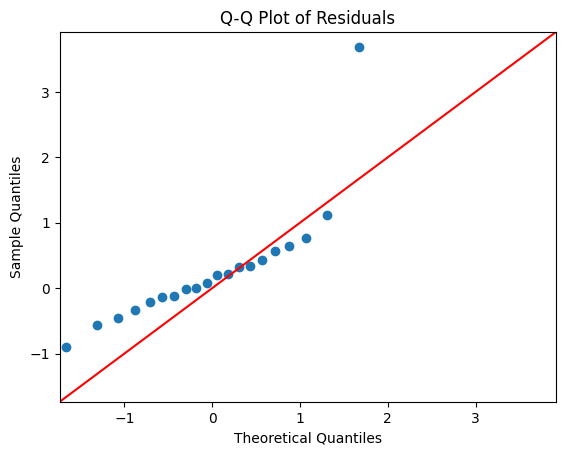

In [ ]:
sm.qqplot(
    all_residuals,
    line="45"
)

plt.title("Q-Q Plot of Residuals")

plt.show()

In [ ]:
np.random.seed(42)

n = 200

df_multiple = pd.DataFrame({
    "Hours_Studied": np.random.uniform(1, 10, n),
    "Attendance": np.random.uniform(60, 100, n),
    "Previous_Grade": np.random.uniform(50, 95, n),
    "Sleep_Hours": np.random.uniform(4, 9, n)
})

In [ ]:
noise = np.random.normal(
    loc=0,
    scale=4,
    size=n
)

df_multiple["Exam_Score"] = (
    10
    + 3.0 * df_multiple["Hours_Studied"]
    + 0.20 * df_multiple["Attendance"]
    + 0.35 * df_multiple["Previous_Grade"]
    + 0.60 * df_multiple["Sleep_Hours"]
    + noise
)

df_multiple.head()

,Hours_Studied,Attendance,Previous_Grade,Sleep_Hours,Exam_Score
0,4.371,85.681,54.641,4.845,59.118
1,9.556,63.366,90.615,5.393,88.179
2,7.588,66.465,72.736,4.885,81.974
3,6.388,95.942,87.191,4.444,86.917
4,2.404,84.257,64.402,4.603,65.739


In [ ]:
df_multiple.describe()

,Hours_Studied,Attendance,Previous_Grade,Sleep_Hours,Exam_Score
count,200.000,200.000,200.000,200.000,200.000
mean,5.356,80.175,73.430,6.394,71.603
std,2.654,11.720,13.829,1.394,10.224
min,1.050,60.202,50.488,4.091,47.491
25%,3.057,70.459,61.498,5.180,63.781
50%,5.450,81.666,73.643,6.336,71.761
75%,7.812,89.688,86.500,7.622,79.324
max,9.882,99.620,94.987,8.950,100.103


In [ ]:
correlation_matrix = df_multiple.corr()

correlation_matrix

,Hours_Studied,Attendance,Previous_Grade,Sleep_Hours,Exam_Score
Hours_Studied,1.000,-0.027,-0.046,-0.033,0.787
Attendance,-0.027,1.000,-0.124,0.071,0.105
Previous_Grade,-0.046,-0.124,1.000,0.061,0.410
Sleep_Hours,-0.033,0.071,0.061,1.000,0.067
Exam_Score,0.787,0.105,0.410,0.067,1.000


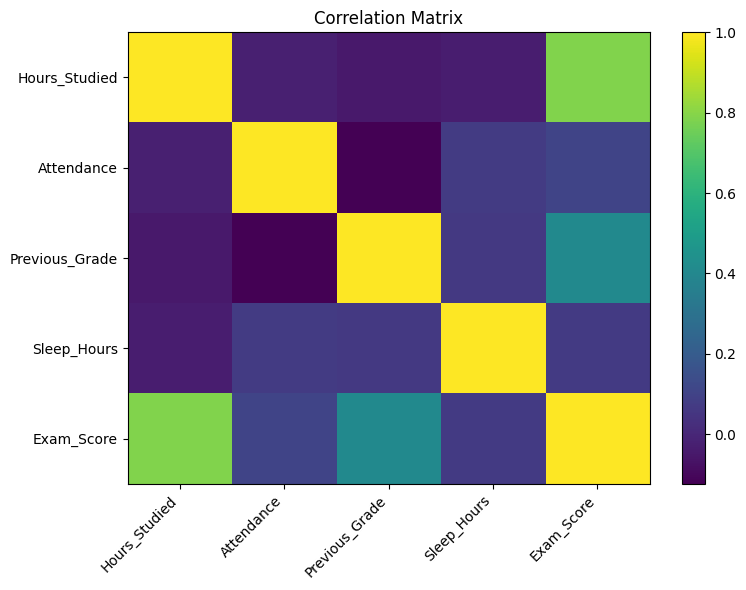

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Grade",
    "Sleep_Hours"
]

X = df_multiple[features]

y = df_multiple["Exam_Score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
multiple_model = LinearRegression()

multiple_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
y_pred = multiple_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

MAE:  2.949
MSE:  13.159
RMSE: 3.628
R²:   0.886


In [ ]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,Hours_Studied,3.110
1,Attendance,0.152
2,Previous_Grade,0.348
3,Sleep_Hours,0.369


In [ ]:
coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
0,Hours_Studied,3.110
3,Sleep_Hours,0.369
2,Previous_Grade,0.348
1,Attendance,0.152


In [ ]:
print(
    "Intercept:",
    multiple_model.intercept_
)

display(coefficients)

Intercept: 14.669470948348987


,Feature,Coefficient
0,Hours_Studied,3.110
1,Attendance,0.152
2,Previous_Grade,0.348
3,Sleep_Hours,0.369


In [ ]:
equation = f"Exam Score = {multiple_model.intercept_:.3f}"

for feature, coef in zip(
    features,
    multiple_model.coef_
):
    equation += f" + ({coef:.3f} × {feature})"

print(equation)

Exam Score = 14.669 + (3.110 × Hours_Studied) + (0.152 × Attendance) + (0.348 × Previous_Grade) + (0.369 × Sleep_Hours)


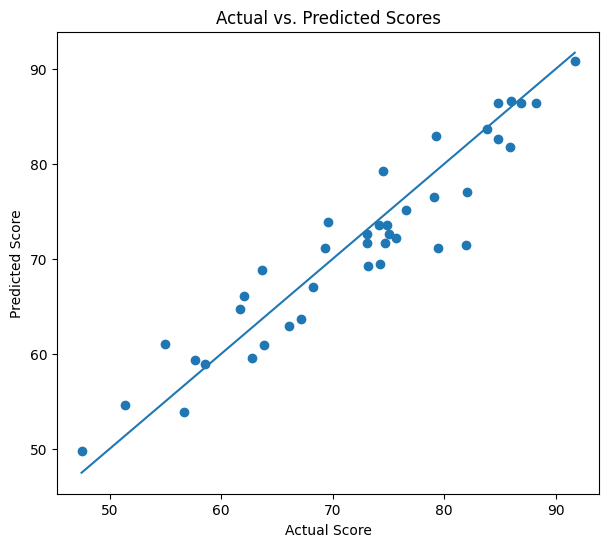

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs. Predicted Scores")

plt.show()

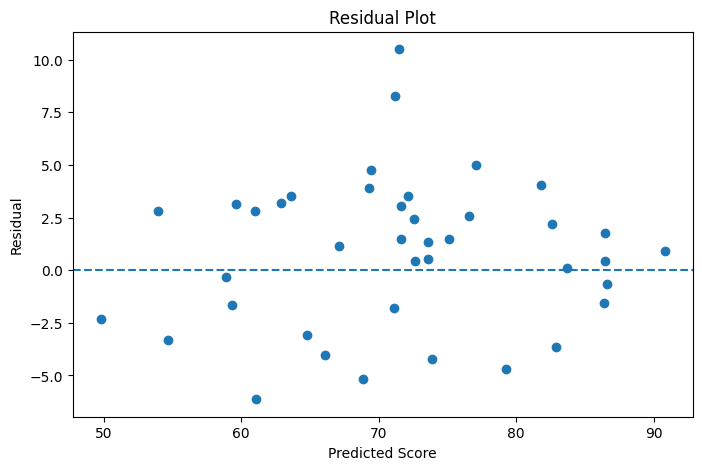

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [ ]:
new_student = pd.DataFrame({
    "Hours_Studied": [7],
    "Attendance": [90],
    "Previous_Grade": [82],
    "Sleep_Hours": [7]
})

In [ ]:
prediction = multiple_model.predict(
    new_student
)

print(
    f"Predicted Exam Score: "
    f"{prediction[0]:.2f}"
)

Predicted Exam Score: 81.25


In [ ]:
train_predictions = multiple_model.predict(
    X_train
)

test_predictions = multiple_model.predict(
    X_test
)

train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

print(
    f"Training R²: {train_r2:.3f}"
)

print(
    f"Testing R²:  {test_r2:.3f}"
)

Training R²: 0.845
Testing R²:  0.886


In [ ]:
X_stats = sm.add_constant(
    df_multiple[features]
)

ols_model = sm.OLS(
    df_multiple["Exam_Score"],
    X_stats
).fit()

print(
    ols_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     287.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.61e-80
Time:                        05:21:49   Log-Likelihood:                -555.25
No. Observations:                 200   AIC:                             1121.
Df Residuals:                     195   BIC:                             1137.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             14.2743      2.882      4.

In [ ]:
print("=" * 50)
print("LINEAR REGRESSION MODEL SUMMARY")
print("=" * 50)

print(
    f"Training observations: "
    f"{len(X_train)}"
)

print(
    f"Testing observations: "
    f"{len(X_test)}"
)

print(
    f"\nIntercept: "
    f"{multiple_model.intercept_:.3f}"
)

print("\nCoefficients:")

for feature, coefficient in zip(
    features,
    multiple_model.coef_
):
    print(
        f"{feature:20s}: "
        f"{coefficient:.3f}"
    )

print("\nPerformance")

print(
    f"MAE:  "
    f"{mean_absolute_error(y_test, test_predictions):.3f}"
)

print(
    f"RMSE: "
    f"{np.sqrt(mean_squared_error(y_test, test_predictions)):.3f}"
)

print(
    f"R²:   "
    f"{r2_score(y_test, test_predictions):.3f}"
)

LINEAR REGRESSION MODEL SUMMARY
Training observations: 160
Testing observations: 40

Intercept: 14.669

Coefficients:
Hours_Studied       : 3.110
Attendance          : 0.152
Previous_Grade      : 0.348
Sleep_Hours         : 0.369

Performance
MAE:  2.949
RMSE: 3.628
R²:   0.886
